# Modelos locales con límite de 4 GB

Comparación complementaria de diez modelos pequeños con un límite de memoria medida de 4 GB.

Este notebook solo lee resultados guardados. Ejecutar todas las celdas no descarga modelos, no consulta servicios y no sobrescribe las mediciones.

## Método y alcance

Son 24 pruebas, tres repeticiones y 720 respuestas. Los tres jueces son `aya-expanse:8b`, `mistral-nemo:12b` y `phi4:14b`. El contexto configurado es 4096 y `thinking` está desactivado. Los tokens/s son la mediana, no la media usada en los otros estudios.

La fidelidad es la media de las notas consolidadas de los jueces, entre 0 y 1. No adversarial corresponde al grupo llamado fácil en el informe original. No equivale a validación humana. Se conservan los votos y respuestas completos. El campo histórico `ttft` mide `prompt_eval_duration` de Ollama. Se presenta como tiempo de procesamiento del prompt, no como latencia observada hasta el primer token. La estabilidad mide la proporción de preguntas con el mismo veredicto en todas sus repeticiones.

La viabilidad se calcula con la VRAM observada en un equipo de mayor capacidad. No acredita una prueba física en una GPU de 4 GB. Los campos vacíos de procesador y contexto asignado no permiten reconstruir cuánto trabajo se descargó a CPU.

In [1]:
import json
import sys
from pathlib import Path


sys.dont_write_bytecode = True


YELLOW = "\033[33m"


CYAN = "\033[36m"


GREEN = "\033[32m"


RESET = "\033[0m"


PALETTE = (
    "#89b4fa",
    "#cba6f7",
    "#f38ba8",
    "#b4befe",
    "#fab387",
    "#a6e3a1",
    "#f9e2af",
    "#94e2d5",
    "#74c7ec",
    "#eba0ac",
)


def info(text: str, highlight: object = "", after: str = "") -> None:
    """Resalta un dato y devuelve el resto del mensaje al cian."""
    message = text.rstrip(". ")
    if highlight != "":
        message += f" {GREEN}{highlight}{CYAN}"
    if after:
        message += f" {after.rstrip('. ')}"
    print(f"{YELLOW}[*]{RESET} {CYAN}{message}.{RESET}")


def read_json(path: Path) -> dict:
    with path.open(encoding="utf-8-sig") as stream:
        return json.load(stream)


def markdown_table(rows: list[dict], columns: dict[str, str]) -> str:
    from tabulate import tabulate

    return tabulate(
        [
            [
                f"{row[key]:.4f}".rstrip("0").rstrip(".")
                if isinstance(row[key], float)
                else row[key]
                for key in columns
            ]
            for row in rows
        ],
        headers=list(columns.values()),
        tablefmt="github",
        disable_numparse=True,
    )


def show_table(rows: list[dict], columns: dict[str, str]) -> None:
    from IPython.display import Markdown, display

    display(Markdown(markdown_table(rows, columns)))


def plot_metrics(rows: list[dict], metrics: list[tuple[str, str]], title: str):
    """Dos paneles horizontales para conservar etiquetas legibles."""
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    style = {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "axes.edgecolor": "#bcc2cc",
        "axes.labelcolor": "#414654",
        "xtick.color": "#565e6d",
        "ytick.color": "#252a34",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "svg.fonttype": "none",
    }
    with mpl.rc_context(style):
        height = max(3.7, len(rows) * 0.42 + 1.4)
        figure, axes = plt.subplots(
            1,
            len(metrics),
            figsize=(13, height),
            layout="constrained",
            squeeze=False,
            sharey=True,
        )
        labels = [str(row["label"]) for row in rows]
        colors = [row.get("color", PALETTE[index % len(PALETTE)]) for index, row in enumerate(rows)]
        for axis, (key, caption) in zip(axes[0], metrics, strict=True):
            values = [row[key] for row in rows]
            bars = axis.barh(range(len(labels)), values, color=colors, height=0.64, zorder=3)
            axis.set_yticks(range(len(labels)), labels)
            axis.set_title(caption, loc="left")
            axis.set_axisbelow(True)
            axis.grid(axis="x", color="#e9ebef", linewidth=0.8)
            axis.tick_params(axis="y", length=0, pad=8)
            axis.margins(x=0.2)
            axis.bar_label(
                bars,
                labels=[f"{value:.3f}".rstrip("0").rstrip(".") for value in values],
                padding=5,
                fontsize=9,
            )
        axes[0, 0].set_ylim(len(labels) - 0.5, -0.5)
        figure.suptitle(title, fontsize=15, weight="bold", color="#252a34")
    plt.close(figure)
    return figure


def summarize_small(data: dict) -> list[dict]:
    """Presenta las métricas ya guardadas en el estudio de 4 GB."""
    return [
        {
            "label": row["model"],
            "easy": row["fidelity_easy"],
            "adversarial": row["fidelity_adversarial"],
            "hallucinations": row["hallucinations"],
            "language": row["language_ko"],
            "disagreements": row["disagreements"],
            "unanimity": row["judge_unanimity"],
            "stability": row["stability"],
            "vram": row["max_vram_gb"],
            "tps": row["median_tps"],
            "prompt_ms": row["ttft_p50_ms"],
            "responses": row["generated"],
            "within_budget": "Sí" if row["viable_4gb"] else "No",
            "kappa": row["fleiss_kappa"],
        }
        for row in data["summary"]
    ]


relative = Path("llm/low-resource")
here = Path.cwd().resolve()
benchmarks = next(
    parent / "docs/benchmarks"
    for parent in (here, *here.parents)
    if (parent / "docs/benchmarks" / relative / "results.json").is_file()
)

study = benchmarks / relative
data = read_json(study / "results.json")
info("Resultados guardados de", relative.as_posix(), "cargados")

rows = summarize_small(data)

[*] Resultados guardados de llm/low-resource cargados.


## Resultados

Los JSON conservan las mediciones originales.

### Calidad

In [2]:
show_table(
    rows,
    {
        "label": "Modelo",
        "easy": "Fid. no adv.",
        "adversarial": "Fid. adv.",
        "hallucinations": "Aluc.",
        "language": "Idioma",
        "disagreements": "Discrepa",
        "unanimity": "Acuerdo",
    },
)

| Modelo           | Fid. no adv.   | Fid. adv.   | Aluc.   | Idioma   | Discrepa   | Acuerdo   |
|------------------|----------------|-------------|---------|----------|------------|-----------|
| granite3.3:2b    | 0.861          | 0.944       | 0       | 0        | 4          | 0.653     |
| llama3.2:3b      | 0.847          | 0.889       | 0       | 0        | 3          | 0.556     |
| phi4-mini:3.8b   | 0.847          | 0.861       | 0       | 1        | 4          | 0.583     |
| qwen3:0.6b       | 0.722          | 0.792       | 0       | 0        | 9          | 0.222     |
| qwen3:1.7b       | 0.875          | 0.75        | 0       | 0        | 12         | 0.458     |
| llama3.2:1b      | 0.722          | 0.708       | 1       | 0        | 13         | 0.222     |
| qwen3:4b         | 0.722          | 0.694       | 0       | 4        | 14         | 0.403     |
| gemma3:1b        | 0.833          | 0.625       | 0       | 0        | 9          | 0.333     |
| deepseek-r1:1.5b | 0.75           | 0.625       | 1       | 2        | 19         | 0.111     |
| gemma3:4b        | 0.875          | 0.833       | 0       | 0        | 9          | 0.611     |

### Recursos

In [3]:
show_table(
    rows,
    {
        "label": "Modelo",
        "vram": "VRAM GB",
        "tps": "Tokens/s",
        "prompt_ms": "Prompt p50 ms",
        "stability": "Estabilidad",
        "within_budget": "≤ 4 GB",
        "kappa": "κ Fleiss",
    },
)

| Modelo           | VRAM GB   | Tokens/s   | Prompt p50 ms   | Estabilidad   | ≤ 4 GB   | κ Fleiss   |
|------------------|-----------|------------|-----------------|---------------|----------|------------|
| granite3.3:2b    | 1.958     | 228.48     | 27.174          | 0.833         | Sí       | 0.053      |
| llama3.2:3b      | 2.561     | 193.636    | 22.732          | 0.875         | Sí       | 0.075      |
| phi4-mini:3.8b   | 3.063     | 173.971    | 21.218          | 0.917         | Sí       | 0.115      |
| qwen3:0.6b       | 0.981     | 443.901    | 10.478          | 0.875         | Sí       | -0.025     |
| qwen3:1.7b       | 1.782     | 271.586    | 15.676          | 1             | Sí       | 0.024      |
| llama3.2:1b      | 1.622     | 324.322    | 10.934          | 0.75          | Sí       | -0.054     |
| qwen3:4b         | 3.291     | 142.024    | 28.38           | 0.708         | Sí       | 0.053      |
| gemma3:1b        | 1.2       | 317.24     | 13.57           | 1             | Sí       | 0.05       |
| deepseek-r1:1.5b | 1.315     | 329.568    | 14.732          | 0.625         | Sí       | -0.057     |
| gemma3:4b        | 4.05      | 146.857    | 25.317          | 1             | No       | 0.105      |

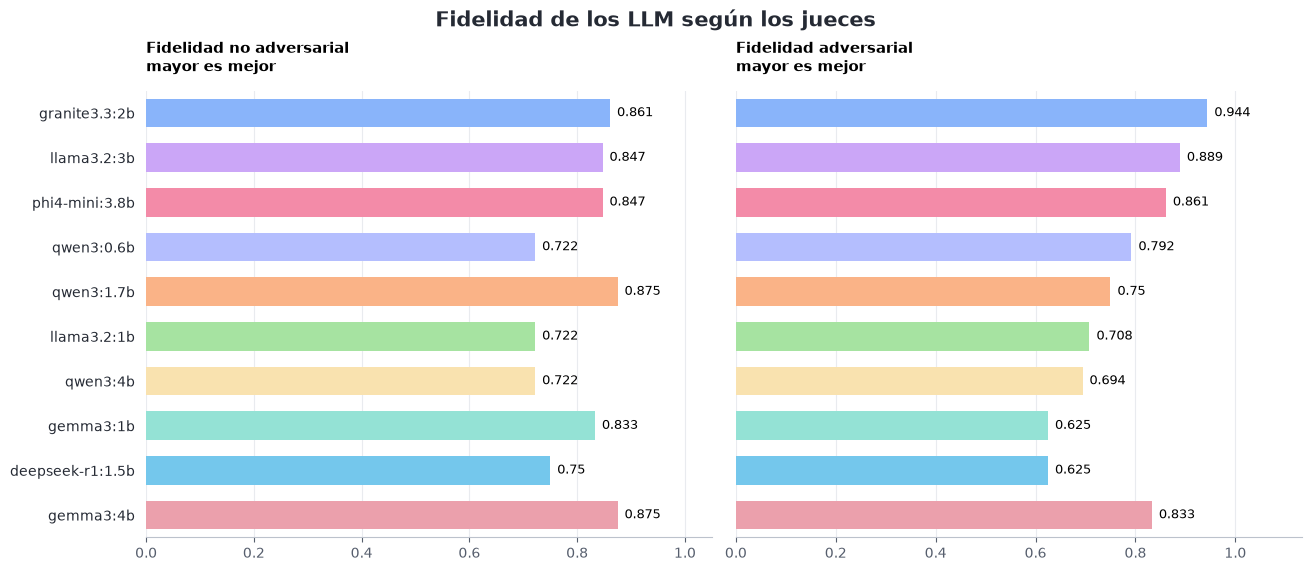

In [4]:
figure_0 = plot_metrics(
    rows,
    [
        ("easy", "Fidelidad no adversarial\nmayor es mejor"),
        ("adversarial", "Fidelidad adversarial\nmayor es mejor"),
    ],
    "Fidelidad de los LLM según los jueces",
)
figure_0

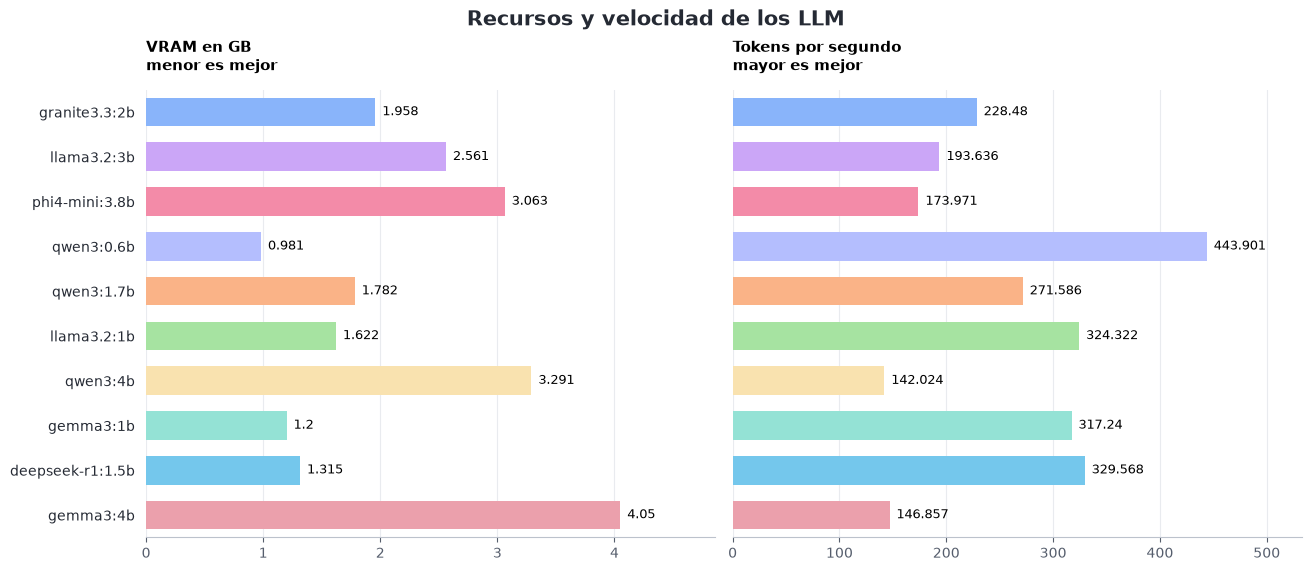

In [5]:
figure_1 = plot_metrics(
    rows,
    [("vram", "VRAM en GB\nmenor es mejor"), ("tps", "Tokens por segundo\nmayor es mejor")],
    "Recursos y velocidad de los LLM",
)
figure_1

## Conclusiones

`granite3.3:2b` queda como candidato provisional. En la GPU de prueba consume
unos 1,96 GB de memoria gráfica, dentro del presupuesto de 4 GB. `gemma3:4b`
lo supera ligeramente, con 4,05 GB.

Los jueces coinciden poco, así que hace falta revisar las respuestas a mano.
La GPU utilizada tenía más de 4 GB. El consumo observado no demuestra que
funcione igual en una tarjeta física de esa capacidad.

## Archivos y reproducción

`measure.py` conserva el método de medición y requiere una ejecución explícita con un directorio nuevo. Consulta el [índice](../../README.md) antes de medir. Las dependencias actuales no garantizan repetir exactamente el entorno histórico ni sus tiempos.